In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# 05 — The positionwise feed-forward network

Attention mixes information across allowed positions. The MLP applies the same nonlinear feature transformation independently at each position:
$F(x)=W_{\mathrm{down}}\mathrm{GELU}(W_{\mathrm{up}}x+b_{\mathrm{up}})+b_{\mathrm{down}}$.
This equation uses column-vector notation; PyTorch Linear stores [out_features,in_features].

We will inspect expansion, nonlinearity, contraction, and the token/feature boundary.

## How to work through this notebook

Run setup once. At each checkpoint, write a prediction and try the small implementation before reading its adjacent reference solution. All reference cells run unchanged from top to bottom; exercise cells contain safe, optional starting points. Numerical checks use CPU float64 unless explicitly noted. Agent-verified reference execution is separate from your learning progress.

In [2]:
from pathlib import Path
import sys, copy, math, inspect
from dataclasses import replace
import torch
from torch import nn
from torch.nn import functional as F
root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/dongxi_llms/decoder_lab.py").exists()), None)
if root is None:
    raise RuntimeError("Open this notebook from inside the Dongxi_LLMs repository")
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
from dongxi_llms.decoder_lab import (
    DecoderConfig, TinyDecoder, DecoderBlock, MultiHeadAttention, MLP, RMSNorm,
    layer_norm, rms_norm, rope, attend, parameter_count, analytical_parameters,
    cost_estimate, teaching_batch, next_token_loss, fit_one_batch)
torch.set_num_threads(1)
torch.manual_seed(505)
DTYPE = torch.float64
def close(actual, expected, atol=1e-10, rtol=1e-8):
    torch.testing.assert_close(actual, expected, atol=atol, rtol=rtol)
print("CPU reference environment:", torch.__version__)


CPU reference environment: 2.14.1+cpu


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from dongxi_llms import decoder_visuals as viz
def show_visual(figure):
    display(figure)
    plt.close(figure)


## Architecture map — your location in the model

The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.

![Architecture map — your location in the model. The highlighted stage is this lesson’s focus. B = batch, T = positions, D = model width, V = vocabulary size. This is a structural map, not measured activations or runtime. The baseline route adds learned position embeddings before the blocks.](../figures/chapter-05/day-05-05_positionwise_mlp-architecture-map.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

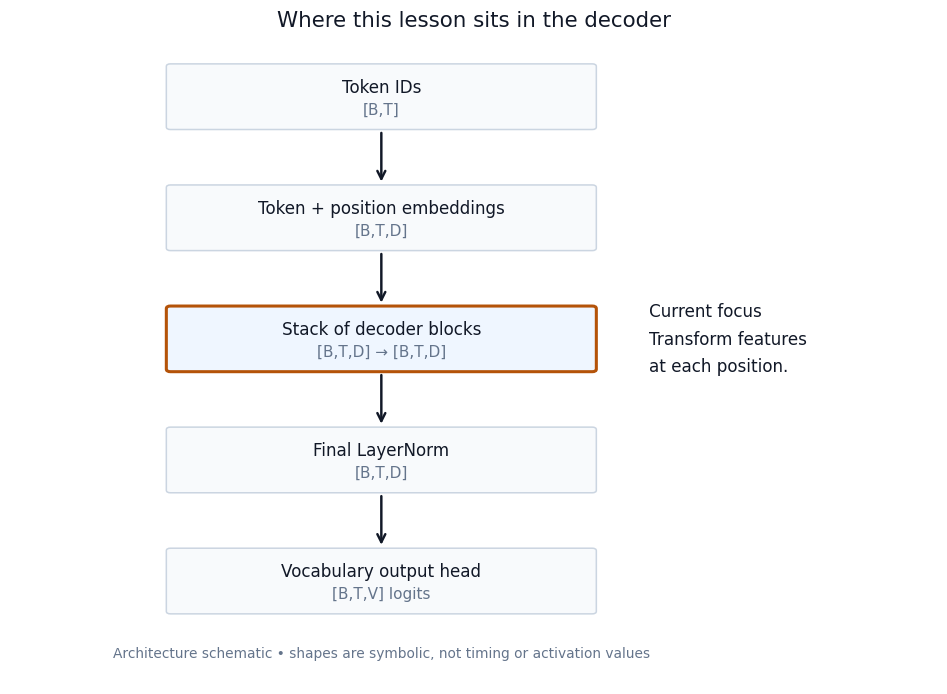

In [4]:
from dongxi_llms import decoder_architecture as architecture
show_visual(architecture.model_map(focus='mlp', modern=False))

## See expansion, nonlinearity, and contraction

Batch B and positions T remain fixed while feature width changes D → F → D. The same matrices are used at every position.

![See expansion, nonlinearity, and contraction. Batch B and positions T remain fixed while feature width changes D → F → D. The same matrices are used at every position.](../figures/chapter-05/day-05-05_positionwise_mlp-architecture-detail.png)

*Saved architecture schematic. The following cell regenerates it; it does not execute or train a model.*

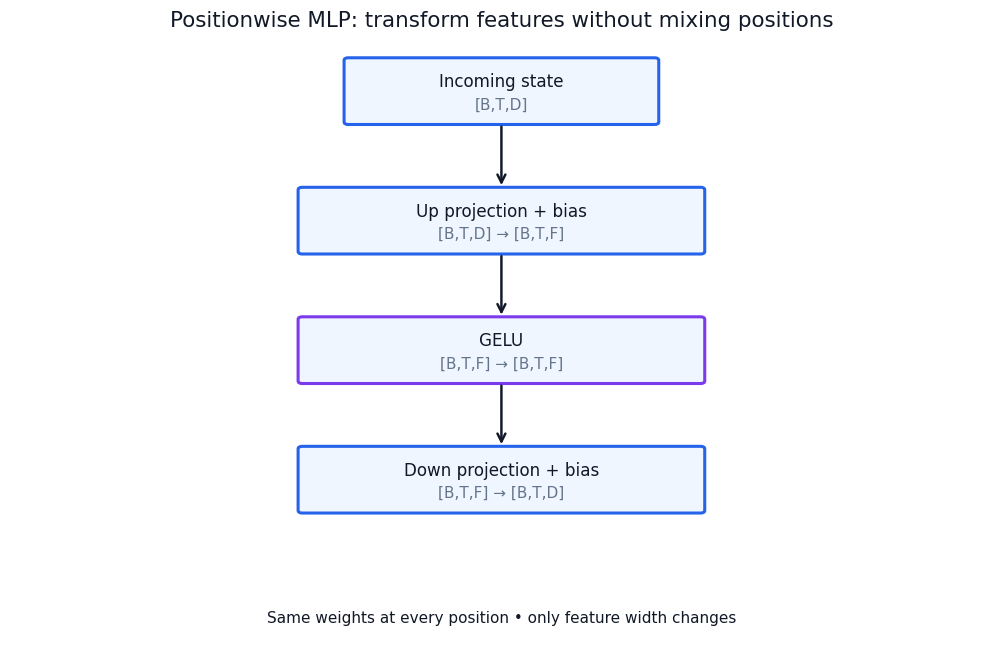

In [5]:
show_visual(architecture.mlp_detail())

### Prediction

## 1. Expose the expanded features

Implement an MLP forward pass explicitly and compare it with the reusable module. Is the wider intermediate tensor a longer token sequence?

**Your prediction:** _Write it here before running the reference._

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [6]:
mlp = MLP(16, 32).double()
x = torch.randn(2, 6, 16, dtype=DTYPE, requires_grad=True)
# Your implementation: expanded = ...; activated = ...; output = ...

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [7]:
expanded = F.linear(x, mlp.up.weight, mlp.up.bias)
activated = F.gelu(expanded)
output = F.linear(activated, mlp.down.weight, mlp.down.bias)
close(output, mlp(x))
print("Input, expansion, output:", x.shape, expanded.shape, output.shape)
print("First position, first 6 features before/after GELU:",
      expanded[0, 0, :6].detach(), activated[0, 0, :6].detach())

Input, expansion, output: torch.Size([2, 6, 16]) torch.Size([2, 6, 32]) torch.Size([2, 6, 16])
First position, first 6 features before/after GELU: tensor([ 0.4799,  0.7145,  0.0747, -0.3225,  0.3596, -0.1380],
       dtype=torch.float64) tensor([ 0.3284,  0.5448,  0.0396, -0.1205,  0.2303, -0.0614],
       dtype=torch.float64)


### Reference explanation

### Why this works

The feature axis expands from 16 to 32 while batch and time stay fixed. GELU is a smooth nonlinear transformation; it is not an attention distribution or probability normalization.


### Visual explanation — See the nonlinear transformation

The dashed line is an identity map. GELU and SiLU change feature values nonlinearly; neither is a probability transformation. SiLU is included as a preview of the gated MLP lesson.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![See the nonlinear transformation. The dashed line is an identity map. GELU and SiLU change feature values nonlinearly; neither is a probability transformation. SiLU is included as a preview of the gated MLP lesson.](../figures/chapter-05/day-05-05_positionwise_mlp-visual-activation.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

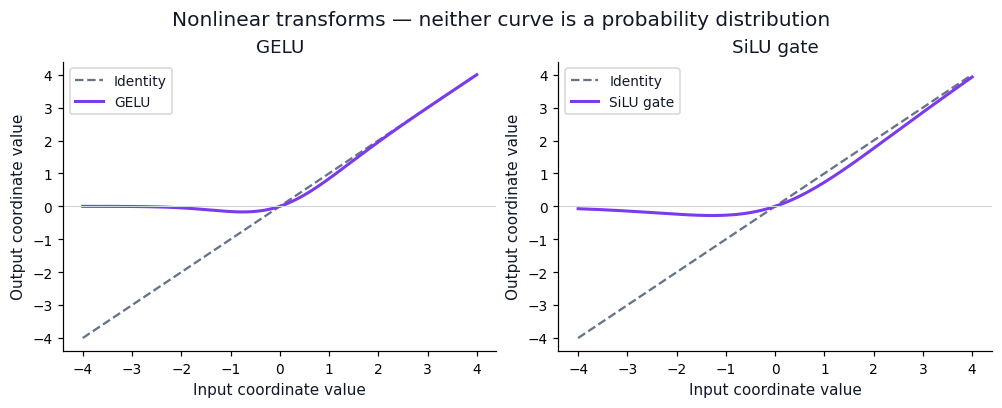

In [8]:
show_visual(viz.activation_curve())

### Visual explanation — Compare expanded and activated features

These are the actual 32 intermediate coordinates at one position. The number of token positions stays unchanged during expansion.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![Compare expanded and activated features. These are the actual 32 intermediate coordinates at one position. The number of token positions stays unchanged during expansion.](../figures/chapter-05/day-05-05_positionwise_mlp-visual-expanded-features.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

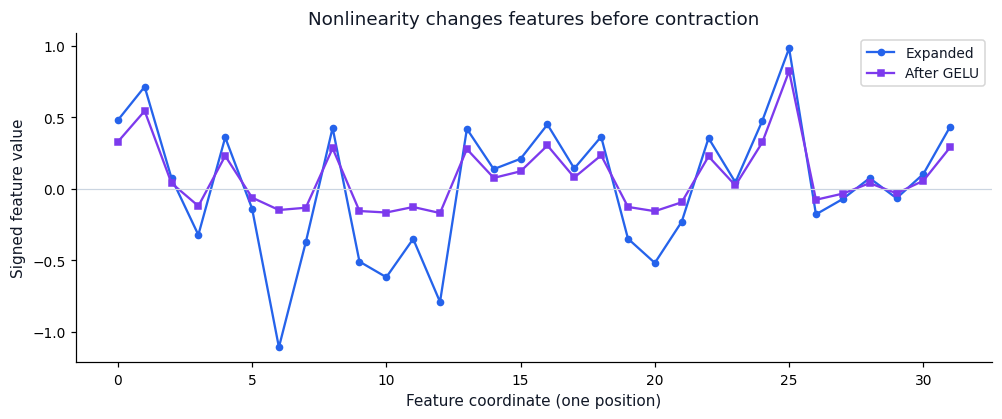

In [9]:
show_visual(viz.features({'Expanded': expanded[0,0], 'After GELU': activated[0,0]}, 'Nonlinearity changes features before contraction'))

### Prediction

## 2. Remove the activation

Show that two affine layers without a nonlinearity collapse into one affine map, including both biases.

**Your prediction:** _Write it here before running the reference._

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [10]:
# Your implementation: combined_weight = ...; combined_bias = ...

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [11]:
combined_weight = mlp.down.weight @ mlp.up.weight
combined_bias = mlp.down.weight @ mlp.up.bias + mlp.down.bias
collapsed = F.linear(x, combined_weight, combined_bias)
linear_path = mlp.down(mlp.up(x))
close(collapsed, linear_path)
assert not torch.allclose(output, collapsed)
print("Affine collapse error:", float((collapsed-linear_path).abs().max().detach()))
print("Removing GELU changes output by:", float((output-collapsed).norm().detach()))

Affine collapse error: 4.440892098500626e-16
Removing GELU changes output by: 3.0252246171037678


### Reference explanation

### Why this works

Expansion alone does not make the composition nonlinear. With the activation removed, the two projections are one affine function, even if their intermediate width is large.


### Prediction

## 3. Perturb one position and follow gradients

Change only position 3 at the MLP input, then backpropagate a loss from position 2. Which input positions can receive gradients through this isolated MLP?

**Your prediction:** _Write it here before running the reference._

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [12]:
# Predict the affected positions before running.

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [13]:
changed = x.detach().clone(); changed[:, 3] += 2
original, perturbed = mlp(x), mlp(changed)
keep = torch.tensor([0, 1, 2, 4, 5])
close(original[:, keep], perturbed[:, keep])
input_gradient = torch.autograd.grad(original[:, 2].square().sum(), x, retain_graph=True)[0]
close(input_gradient[:, [0, 1, 3, 4, 5]], torch.zeros_like(input_gradient[:, [0, 1, 3, 4, 5]]))
original.square().mean().backward()
print("Input gradient norm by position:", input_gradient.norm(dim=-1))
print("Up/down projection gradient norms:",
      float(mlp.up.weight.grad.norm()), float(mlp.down.weight.grad.norm()))

Input gradient norm by position: tensor([[0.0000, 0.0000, 0.7732, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1520, 0.0000, 0.0000, 0.0000]], dtype=torch.float64)
Up/down projection gradient norms: 0.08102975713454313 0.08253370945083031


### Reference explanation

### Why this works

The isolated MLP does not mix positions. Its input can nevertheless already contain context gathered by earlier attention. Shared weights accumulate gradients across positions, just like shared Q/K/V projections.


### Visual explanation — See which positions the isolated MLP changes

Only the perturbed position changes here. Context can already exist in the MLP input, but this operation does not directly mix positions.

The figure uses this lesson’s tensors. Rerun it after changing the preceding experiment.

![See which positions the isolated MLP changes. Only the perturbed position changes here. Context can already exist in the MLP input, but this operation does not directly mix positions.](../figures/chapter-05/day-05-05_positionwise_mlp-visual-positionwise.png)

*Saved reference preview. The code below regenerates this figure from the current lesson state; it does not overwrite the preview.*

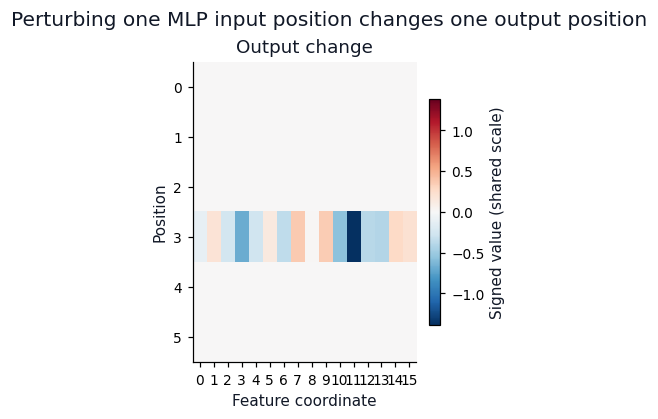

In [14]:
show_visual(viz.matrices([(perturbed-original)[0]], ['Output change'], 'Perturbing one MLP input position changes one output position'))

## Takeaway and evidence boundary

Next: assemble these tested pieces into one causal next-token model and inspect the complete tensor path.

Companion map: [Chapter 5 pathway](../day-05/README.md). Reusable source: [decoder_lab.py](../../src/dongxi_llms/decoder_lab.py). Record your explanation and remaining questions here; the notebook's existence does not mark the lesson complete.